In [11]:
RANKED = {420, 440}
MATCH = {400, 430, 480, 490}
CASUAL = {
    450, 100,          # ARAM
    900, 1010, 1900,   # URF
    1020,              # One for All
    1300,              # Nexus Blitz
    1400,              # Spellbook
    1700, 1710,        # Arena
    2300               # Brawl
}
BOTS = {820, 870, 880, 890}

In [17]:
import json
import pandas as pd

# 读数据
with open("raw_total_IRON.json", "r") as f:
    data = json.load(f)

rows = []
for match in data:
    info = match["info"]
    meta = match["metadata"]
    
    for p in info["participants"]:
        rows.append({
            "match_id":   meta["matchId"],
            "timestamp":  info["gameEndTimestamp"],
            "queueId":    info["queueId"],
            "puuid":      p["puuid"],
            "win":        p["win"],
            "kills":      p["kills"],
            "deaths":     p["deaths"],
            "assists":    p["assists"],
        })

df = pd.DataFrame(rows).sort_values(["puuid", "timestamp"]).reset_index(drop=True)



df_ranked = df[df["queueId"].isin(RANKED)].copy()
df_ranked["next_queue"] = df_ranked.groupby("puuid")["queueId"].shift(-1)
df_ranked["switch_to_entertainment"] = df_ranked["next_queue"].isin(CASUAL)

print(f"Ranked 场次总数: {len(df_ranked)}")
print(f"Switch 事件数: {df_ranked['switch_to_entertainment'].sum()}")
print(f"Switch 比例: {df_ranked['switch_to_entertainment'].mean():.3f}")
print(f"\nqueueId 分布（全部）:")
print(df["queueId"].value_counts())

Ranked 场次总数: 2860
Switch 事件数: 0
Switch 比例: 0.000

queueId 分布（全部）:
queueId
420     2710
400      670
480      150
440      150
450      130
900      110
1700      80
880       20
Name: count, dtype: int64


In [18]:
# 看每个玩家的 queueId 分布
player_queues = df.groupby("puuid")["queueId"].apply(list)

# 找有没有玩家同时有 ranked 和 casual
both = []
for puuid, queues in player_queues.items():
    has_ranked = any(q in RANKED for q in queues)
    has_casual = any(q in CASUAL for q in queues)
    if has_ranked and has_casual:
        both.append(puuid)

print(f"同时有 ranked 和 casual 的玩家: {len(both)}")
print(f"总玩家数: {df['puuid'].nunique()}")

同时有 ranked 和 casual 的玩家: 13
总玩家数: 3310


In [19]:
# 看其中一个玩家的完整序列
sample_puuid = both[0]
player_df = df[df["puuid"] == sample_puuid].sort_values("timestamp")
print(player_df[["timestamp", "queueId", "win"]].to_string())

         timestamp  queueId    win
298  1774416505402      400  False
299  1774416869331      400  False
300  1774419496892      400  False
301  1774421159421      450  False
302  1774659704912      450  False
303  1774663326064      450   True
304  1774665247445      450   True
305  1774666942932      400  False
306  1774673433802      440   True
307  1774675140087      440  False


In [20]:
RANKED  = {420, 440}
MATCH   = {400, 430, 480, 490}
CASUAL  = {450, 100, 900, 1010, 1900, 1020, 1300, 1400, 1700, 1710, 2300}

df["next_queue"] = df.groupby("puuid")["queueId"].shift(-1)

# 三种 switch
df["switch_ranked_to_casual"] = df["queueId"].isin(RANKED) & df["next_queue"].isin(CASUAL)
df["switch_ranked_to_match"]  = df["queueId"].isin(RANKED) & df["next_queue"].isin(MATCH)
df["switch_match_to_casual"]  = df["queueId"].isin(MATCH)  & df["next_queue"].isin(CASUAL)

print(f"ranked → casual : {df['switch_ranked_to_casual'].sum()}")
print(f"ranked → match  : {df['switch_ranked_to_match'].sum()}")
print(f"match  → casual : {df['switch_match_to_casual'].sum()}")

ranked → casual : 5
ranked → match  : 23
match  → casual : 8


In [22]:
import json
import os

tiers = ["IRON", "BRONZE", "SILVER", "GOLD", "PLATINUM", "DIAMOND"]

for tier in tiers:
    fname = f"raw_total_{tier}.json"
    if os.path.exists(fname):
        with open(fname, "r") as f:
            d = json.load(f)
        print(f"{tier}: {len(d)} matches")
    else:
        print(f"{tier}: 文件不存在")

IRON: 400 matches
BRONZE: 797 matches
SILVER: 1197 matches
GOLD: 1597 matches
PLATINUM: 1997 matches
DIAMOND: 2397 matches


In [26]:
import json

all_data = []
tiers = ["IRON", "BRONZE", "SILVER", "GOLD", "PLATINUM", "DIAMOND"]

for tier in tiers:
    with open(f"raw_total_{tier}.json", "r") as f:
        data = json.load(f)
    for match in data:
        info = match["info"]
        meta = match["metadata"]
        for p in info["participants"]:
            all_data.append({
                "match_id":  meta["matchId"],
                "timestamp": info["gameEndTimestamp"],
                "queueId":   info["queueId"],
                "tier":      tier,
                "puuid":     p["puuid"],
                "win":       p["win"],
                "kills":     p["kills"],
                "deaths":    p["deaths"],
                "assists":   p["assists"],
                "totalDamageDealtToChampions": p["totalDamageDealtToChampions"],
                "goldEarned": p["goldEarned"],
                "visionScore": p["visionScore"],
                "gameDuration": info["gameDuration"],
            })

df = pd.DataFrame(all_data).sort_values(["puuid", "timestamp"]).reset_index(drop=True)

# switch 统计
df["next_queue"] = df.groupby("puuid")["queueId"].shift(-1)
df["switch_ranked_to_casual"] = df["queueId"].isin(RANKED) & df["next_queue"].isin(CASUAL)
df["switch_ranked_to_match"]  = df["queueId"].isin(RANKED) & df["next_queue"].isin(MATCH)
df["switch_match_to_casual"]  = df["queueId"].isin(MATCH)  & df["next_queue"].isin(CASUAL)

print(f"总行数: {len(df)}")
print(f"总玩家数: {df['puuid'].nunique()}")
print(f"\nranked → casual : {df['switch_ranked_to_casual'].sum()}")
print(f"ranked → match  : {df['switch_ranked_to_match'].sum()}")
print(f"match  → casual : {df['switch_match_to_casual'].sum()}")

总行数: 85244
总玩家数: 20027

ranked → casual : 42
ranked → match  : 130
match  → casual : 24


In [27]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import numpy as np

# 只用 ranked 场次
df_ranked = df[df["queueId"].isin(RANKED)].copy()

# 构建features
df_ranked["kda"] = (df_ranked["kills"] + df_ranked["assists"]) / df_ranked["deaths"].clip(lower=1)
df_ranked["kda_mean"] = df_ranked.groupby("puuid")["kda"].transform("mean")
df_ranked["kda_gap"] = df_ranked["kda"] - df_ranked["kda_mean"]
df_ranked["loss"] = (~df_ranked["win"]).astype(int)
df_ranked["losing_streak"] = df_ranked.groupby("puuid")["loss"].transform(
    lambda x: x.groupby((x != x.shift()).cumsum()).cumcount()
)
df_ranked["hour"] = pd.to_datetime(df_ranked["timestamp"], unit="ms").dt.hour

features = ["loss", "kda_gap", "losing_streak", "gameDuration", "hour", "visionScore"]
target = "switch_ranked_to_match"

df_model = df_ranked[features + [target]].dropna()

X = df_model[features]
y = df_model[target]

print(f"总样本: {len(X)}")
print(f"Switch=1: {y.sum()}, Switch=0: {(~y).sum()}")
print(f"Switch 比例: {y.mean():.3f}")

# 随机森林
rf = RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42)
rf.fit(X, y)

importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
print("\nFeature Importance:")
print(importances)

总样本: 60140
Switch=1: 130, Switch=0: 60010
Switch 比例: 0.002

Feature Importance:
kda_gap          0.308612
losing_streak    0.201689
gameDuration     0.182250
visionScore      0.153025
hour             0.126993
loss             0.027431
dtype: float64


In [28]:
from sklearn.model_selection import cross_val_score

# 看模型实际预测能力
scores = cross_val_score(rf, X, y, cv=5, scoring="roc_auc")
print(f"ROC-AUC: {scores.mean():.3f} ± {scores.std():.3f}")

# baseline: 全猜0的准确率
print(f"Baseline accuracy: {1 - y.mean():.3f}")

ROC-AUC: 0.747 ± 0.047
Baseline accuracy: 0.998


In [30]:
df_ranked["switch_ranked_to_match"] = df_ranked["switch_ranked_to_match"].astype(int)

model = smf.logit(
    "switch_ranked_to_match ~ loss + kda_gap + losing_streak + gameDuration + C(hour)",
    data=df_ranked
).fit()

print(model.summary())

         Current function value: 0.014487
         Iterations: 35
                             Logit Regression Results                             
Dep. Variable:     switch_ranked_to_match   No. Observations:                60140
Model:                              Logit   Df Residuals:                    60112
Method:                               MLE   Df Model:                           27
Date:                    Sun, 29 Mar 2026   Pseudo R-squ.:                 0.06079
Time:                            21:45:34   Log-Likelihood:                -871.26
converged:                          False   LL-Null:                       -927.66
Covariance Type:                nonrobust   LLR p-value:                 1.872e-12
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        -6.2740      0.422    -14.859      0.000      -7.101      -5.446
C(hour)[T.1]     -0.2505

c:\jojo\ISOM3360\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [31]:
# Model 2: ranked → casual
df_ranked["switch_ranked_to_casual"] = df_ranked["switch_ranked_to_casual"].astype(int)

model2 = smf.logit(
    "switch_ranked_to_casual ~ loss + kda_gap + losing_streak + gameDuration + hour",
    data=df_ranked
).fit(maxiter=200, disp=False)

print("=== Model 2: ranked → casual ===")
print(model2.summary())

=== Model 2: ranked → casual ===
                              Logit Regression Results                             
Dep. Variable:     switch_ranked_to_casual   No. Observations:                60140
Model:                               Logit   Df Residuals:                    60134
Method:                                MLE   Df Model:                            5
Date:                     Sun, 29 Mar 2026   Pseudo R-squ.:                 0.02815
Time:                             21:48:05   Log-Likelihood:                -337.41
converged:                            True   LL-Null:                       -347.19
Covariance Type:                 nonrobust   LLR p-value:                  0.001518
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        -7.4118      0.603    -12.282      0.000      -8.595      -6.229
loss             -0.0480      0.323     -0.149   

In [32]:
# Model 3: match → casual
df_match = df[df["queueId"].isin(MATCH)].copy()
df_match["kda"] = (df_match["kills"] + df_match["assists"]) / df_match["deaths"].clip(lower=1)
df_match["kda_mean"] = df_match.groupby("puuid")["kda"].transform("mean")
df_match["kda_gap"] = df_match["kda"] - df_match["kda_mean"]
df_match["loss"] = (~df_match["win"]).astype(int)
df_match["losing_streak"] = df_match.groupby("puuid")["loss"].transform(
    lambda x: x.groupby((x != x.shift()).cumsum()).cumcount()
)
df_match["hour"] = pd.to_datetime(df_match["timestamp"], unit="ms").dt.hour
df_match["switch_match_to_casual"] = df_match["switch_match_to_casual"].astype(int)

model3 = smf.logit(
    "switch_match_to_casual ~ loss + kda_gap + losing_streak + gameDuration + hour",
    data=df_match
).fit(maxiter=200, disp=False)

print("=== Model 3: match → casual ===")
print(model3.summary())

=== Model 3: match → casual ===
                             Logit Regression Results                             
Dep. Variable:     switch_match_to_casual   No. Observations:                15650
Model:                              Logit   Df Residuals:                    15644
Method:                               MLE   Df Model:                            5
Date:                    Sun, 29 Mar 2026   Pseudo R-squ.:                 0.07204
Time:                            21:48:23   Log-Likelihood:                -166.57
converged:                           True   LL-Null:                       -179.51
Covariance Type:                nonrobust   LLR p-value:                 9.481e-05
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        -8.4449      0.763    -11.062      0.000      -9.941      -6.949
loss             -0.3132      0.422     -0.741      0.458 

In [33]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
import statsmodels.formula.api as smf

def run_model(df_input, target_col, label):
    df_m = df_input.copy()
    df_m["kda"] = (df_m["kills"] + df_m["assists"]) / df_m["deaths"].clip(lower=1)
    df_m["kda_mean"] = df_m.groupby("puuid")["kda"].transform("mean")
    df_m["kda_gap"] = df_m["kda"] - df_m["kda_mean"]
    df_m["loss"] = (~df_m["win"]).astype(int)
    df_m["losing_streak"] = df_m.groupby("puuid")["loss"].transform(
        lambda x: x.groupby((x != x.shift()).cumsum()).cumcount()
    )
    df_m["hour"] = pd.to_datetime(df_m["timestamp"], unit="ms").dt.hour
    df_m[target_col] = df_m[target_col].astype(int)

    features = ["loss", "kda_gap", "losing_streak", "gameDuration", "hour", "visionScore"]
    df_clean = df_m[features + [target_col]].dropna()
    X = df_clean[features]
    y = df_clean[target_col]

    print(f"\n{'='*50}")
    print(f"  {label}")
    print(f"{'='*50}")
    print(f"Switch=1: {y.sum()}, Switch=0: {(~y.astype(bool)).sum()}")

    # 随机森林
    rf = RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42)
    rf.fit(X, y)
    auc = cross_val_score(rf, X, y, cv=5, scoring="roc_auc").mean()
    importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
    print(f"\nRandom Forest AUC: {auc:.3f}")
    print("Feature Importance:")
    print(importances)

    # Logistic Regression
    model = smf.logit(
        f"{target_col} ~ loss + kda_gap + losing_streak + gameDuration + hour",
        data=df_m
    ).fit(maxiter=200, disp=False)
    print("\nLogistic Regression:")
    print(model.summary().tables[1])

# Model 1: ranked → match
run_model(df_ranked, "switch_ranked_to_match", "Model 1: ranked → match")

# Model 2: ranked → casual
run_model(df_ranked, "switch_ranked_to_casual", "Model 2: ranked → casual")

# Model 3: match → casual
df_match = df[df["queueId"].isin(MATCH)].copy()
df_match["switch_match_to_casual"] = df["switch_match_to_casual"]
run_model(df_match, "switch_match_to_casual", "Model 3: match → casual")


  Model 1: ranked → match
Switch=1: 130, Switch=0: 60010

Random Forest AUC: 0.747
Feature Importance:
kda_gap          0.308612
losing_streak    0.201689
gameDuration     0.182250
visionScore      0.153025
hour             0.126993
loss             0.027431
dtype: float64

Logistic Regression:
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        -6.4177      0.344    -18.660      0.000      -7.092      -5.744
loss              0.2368      0.186      1.273      0.203      -0.128       0.601
kda_gap           0.1320      0.042      3.116      0.002       0.049       0.215
losing_streak     0.1021      0.010     10.544      0.000       0.083       0.121
gameDuration   5.926e-05      0.000      0.361      0.718      -0.000       0.000
hour             -0.0327      0.012     -2.778      0.005      -0.056      -0.010

  Model 2: ranked → casual
Switch=1: 42, Switc

In [36]:
def run_vol_model(df_input, target_col, label):
    df_m = df_input.copy().sort_values(["puuid", "timestamp"])
    df_m["kda"] = (df_m["kills"] + df_m["assists"]) / df_m["deaths"].clip(lower=1)
    df_m["AvgPerf"] = df_m.groupby("puuid")["kda"].transform(
        lambda x: x.expanding().mean().shift(1)
    )
    df_m["Volatility"] = df_m.groupby("puuid")["kda"].transform(
        lambda x: x.expanding().std().shift(1)
    )
    df_m["hour"] = pd.to_datetime(df_m["timestamp"], unit="ms").dt.hour  # ← 加这行
    df_m[target_col] = df_m[target_col].astype(int)
    df_clean = df_m.dropna(subset=["AvgPerf", "Volatility"])

    print(f"\n{'='*50}")
    print(f"  {label}")
    print(f"{'='*50}")
    print(f"Switch=1: {df_clean[target_col].sum()}, Switch=0: {(df_clean[target_col]==0).sum()}")

    features_vol = ["Volatility", "AvgPerf", "hour", "gameDuration"]
    X = df_clean[features_vol]
    y = df_clean[target_col]

    rf = RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42)
    rf.fit(X, y)
    auc = cross_val_score(rf, X, y, cv=5, scoring="roc_auc").mean()
    importances = pd.Series(rf.feature_importances_, index=features_vol).sort_values(ascending=False)
    print(f"\nRandom Forest AUC: {auc:.3f}")
    print("Feature Importance:")
    print(importances)

    model = smf.logit(
        f"{target_col} ~ Volatility + AvgPerf + hour + gameDuration",
        data=df_clean
    ).fit(maxiter=200, disp=False)
    print("\nLogistic Regression:")
    print(model.summary().tables[1])

run_vol_model(df_ranked, "switch_ranked_to_match", "Volatility Model 1: ranked → match")
run_vol_model(df_ranked, "switch_ranked_to_casual", "Volatility Model 2: ranked → casual")
run_vol_model(df_match, "switch_match_to_casual", "Volatility Model 3: match → casual")


  Volatility Model 1: ranked → match
Switch=1: 122, Switch=0: 32402

Random Forest AUC: 0.690
Feature Importance:
Volatility      0.306662
gameDuration    0.289235
AvgPerf         0.246918
hour            0.157185
dtype: float64

Logistic Regression:
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -5.2915      0.336    -15.768      0.000      -5.949      -4.634
Volatility       0.3572      0.055      6.439      0.000       0.248       0.466
AvgPerf         -0.2042      0.058     -3.500      0.000      -0.319      -0.090
hour            -0.0422      0.013     -3.371      0.001      -0.067      -0.018
gameDuration     0.0002      0.000      1.172      0.241      -0.000       0.001

  Volatility Model 2: ranked → casual
Switch=1: 35, Switch=0: 32489

Random Forest AUC: 0.582
Feature Importance:
Volatility      0.323318
gameDuration    0.276273
AvgPerf         

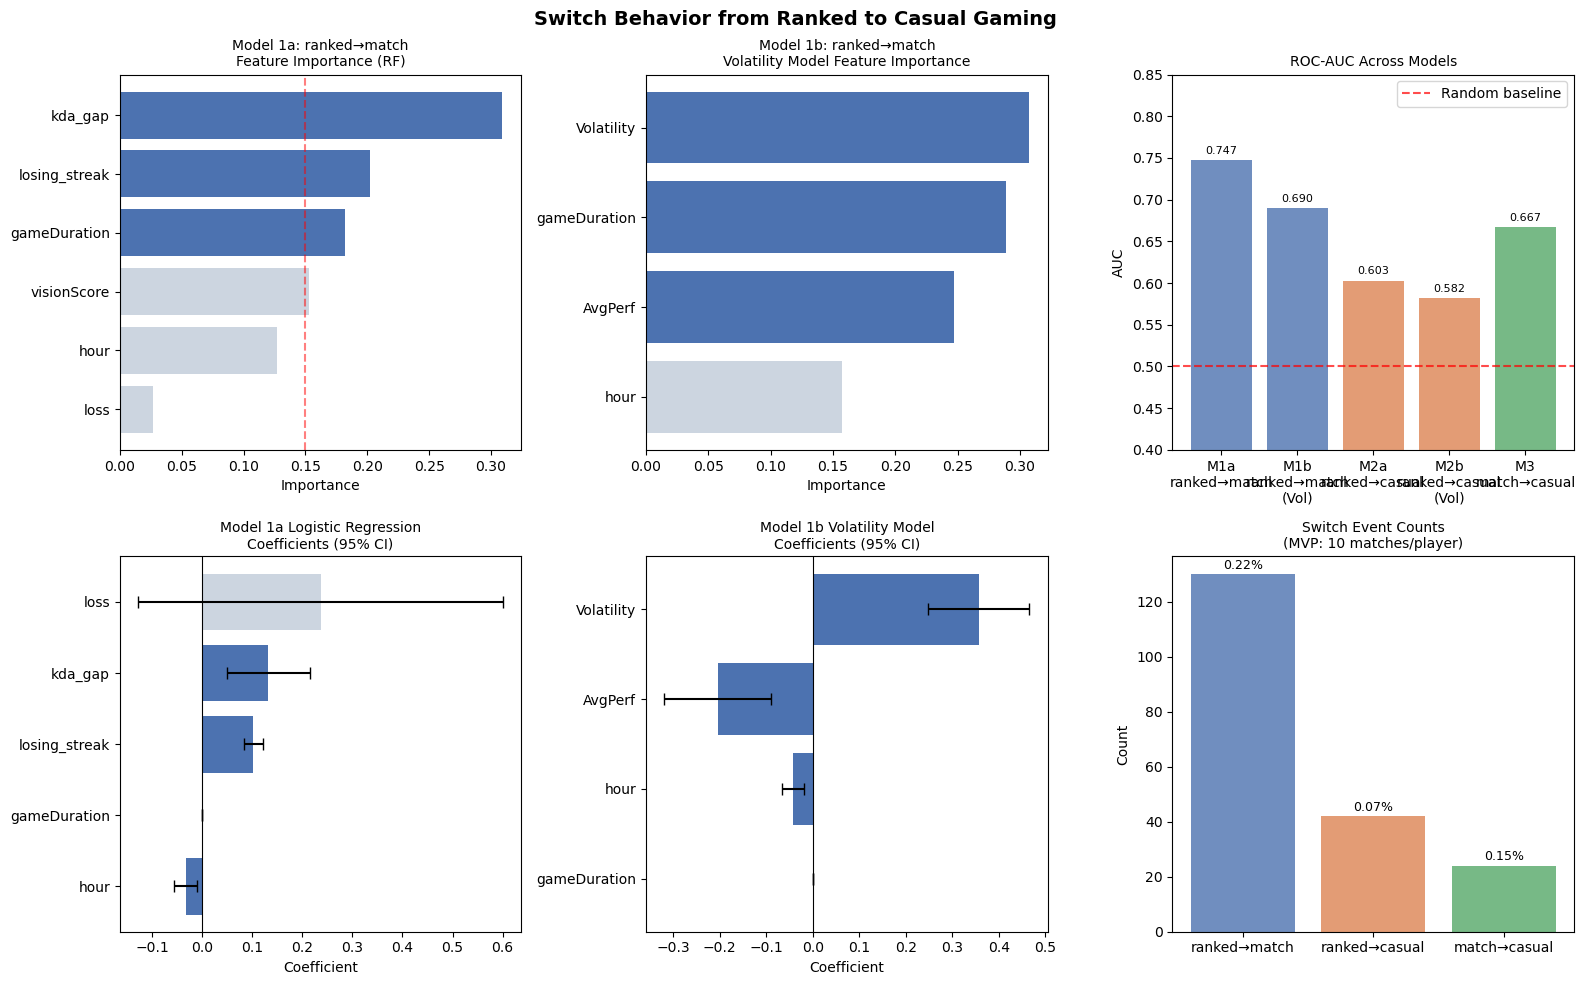

saved: results_draft.png


In [37]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Switch Behavior from Ranked to Casual Gaming", fontsize=14, fontweight="bold")

# ── 1. Feature Importance Model 1 (Loss/KDA model) ──
ax1 = axes[0, 0]
features1 = ["kda_gap", "losing_streak", "gameDuration", "visionScore", "hour", "loss"]
importance1 = [0.309, 0.202, 0.182, 0.153, 0.127, 0.027]
colors1 = ["#4C72B0" if i < 3 else "#CCD5E0" for i in range(len(features1))]
ax1.barh(features1[::-1], importance1[::-1], color=colors1[::-1])
ax1.set_title("Model 1a: ranked→match\nFeature Importance (RF)", fontsize=10)
ax1.set_xlabel("Importance")
ax1.axvline(x=0.15, color="red", linestyle="--", alpha=0.5, label="threshold")

# ── 2. Feature Importance Volatility Model 1 ──
ax2 = axes[0, 1]
features2 = ["Volatility", "gameDuration", "AvgPerf", "hour"]
importance2 = [0.307, 0.289, 0.247, 0.157]
colors2 = ["#4C72B0" if i < 3 else "#CCD5E0" for i in range(len(features2))]
ax2.barh(features2[::-1], importance2[::-1], color=colors2[::-1])
ax2.set_title("Model 1b: ranked→match\nVolatility Model Feature Importance", fontsize=10)
ax2.set_xlabel("Importance")

# ── 3. AUC 比较 ──
ax3 = axes[0, 2]
models = ["M1a\nranked→match", "M1b\nranked→match\n(Vol)", "M2a\nranked→casual", "M2b\nranked→casual\n(Vol)", "M3\nmatch→casual"]
aucs = [0.747, 0.690, 0.603, 0.582, 0.667]
colors_auc = ["#4C72B0", "#4C72B0", "#DD8452", "#DD8452", "#55A868"]
bars = ax3.bar(models, aucs, color=colors_auc, alpha=0.8)
ax3.axhline(y=0.5, color="red", linestyle="--", alpha=0.7, label="Random baseline")
ax3.set_ylim(0.4, 0.85)
ax3.set_title("ROC-AUC Across Models", fontsize=10)
ax3.set_ylabel("AUC")
ax3.legend()
for bar, auc in zip(bars, aucs):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f"{auc:.3f}", ha="center", va="bottom", fontsize=8)

# ── 4. Logistic Regression 系数 Model 1a ──
ax4 = axes[1, 0]
coefs1a = {"loss": 0.237, "kda_gap": 0.132, "losing_streak": 0.102,
           "gameDuration": 0.00006, "hour": -0.033}
ci_low1a = {"loss": -0.128, "kda_gap": 0.049, "losing_streak": 0.083,
            "gameDuration": -0.0001, "hour": -0.056}
ci_high1a = {"loss": 0.601, "kda_gap": 0.215, "losing_streak": 0.121,
             "gameDuration": 0.0002, "hour": -0.010}
vars1a = list(coefs1a.keys())
coef_vals = list(coefs1a.values())
err_low = [coefs1a[v] - ci_low1a[v] for v in vars1a]
err_high = [ci_high1a[v] - coefs1a[v] for v in vars1a]
colors_coef = ["#4C72B0" if (ci_low1a[v] > 0 or ci_high1a[v] < 0) else "#CCD5E0" for v in vars1a]
ax4.barh(vars1a[::-1], coef_vals[::-1],
         xerr=[err_low[::-1], err_high[::-1]],
         color=colors_coef[::-1], capsize=4)
ax4.axvline(x=0, color="black", linewidth=0.8)
ax4.set_title("Model 1a Logistic Regression\nCoefficients (95% CI)", fontsize=10)
ax4.set_xlabel("Coefficient")

# ── 5. Logistic Regression 系数 Volatility Model 1b ──
ax5 = axes[1, 1]
coefs1b = {"Volatility": 0.357, "AvgPerf": -0.204, "hour": -0.042, "gameDuration": 0.0002}
ci_low1b = {"Volatility": 0.248, "AvgPerf": -0.319, "hour": -0.067, "gameDuration": -0.0001}
ci_high1b = {"Volatility": 0.466, "AvgPerf": -0.090, "hour": -0.018, "gameDuration": 0.001}
vars1b = list(coefs1b.keys())
coef_vals1b = list(coefs1b.values())
err_low1b = [coefs1b[v] - ci_low1b[v] for v in vars1b]
err_high1b = [ci_high1b[v] - coefs1b[v] for v in vars1b]
colors_coef1b = ["#4C72B0" if (ci_low1b[v] > 0 or ci_high1b[v] < 0) else "#CCD5E0" for v in vars1b]
ax5.barh(vars1b[::-1], coef_vals1b[::-1],
         xerr=[err_low1b[::-1], err_high1b[::-1]],
         color=colors_coef1b[::-1], capsize=4)
ax5.axvline(x=0, color="black", linewidth=0.8)
ax5.set_title("Model 1b Volatility Model\nCoefficients (95% CI)", fontsize=10)
ax5.set_xlabel("Coefficient")

# ── 6. Switch 事件数 ──
ax6 = axes[1, 2]
switch_types = ["ranked→match", "ranked→casual", "match→casual"]
switch_counts = [130, 42, 24]
total_counts = [60140, 60140, 15650]
switch_pct = [c/t*100 for c, t in zip(switch_counts, total_counts)]
bars6 = ax6.bar(switch_types, switch_counts, color=["#4C72B0", "#DD8452", "#55A868"], alpha=0.8)
ax6.set_title("Switch Event Counts\n(MVP: 10 matches/player)", fontsize=10)
ax6.set_ylabel("Count")
for bar, pct in zip(bars6, switch_pct):
    ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f"{pct:.2f}%", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("results_draft.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved: results_draft.png")